# 04b - Polar reference detection

## Objectif
Détecter les défauts en comparant chaque image à une référence construite à partir d’images OK.

## Idée
- segmenter la pièce
- extraire deux anneaux :
  - outer ring
  - inner ring
- transformer ces anneaux en bandes polaires
- comparer ces bandes à une moyenne d’images OK
- mesurer l’écart anormal

In [25]:
# ==========================================
# 1. Imports
# ==========================================

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import random

from src.io_utils import list_images, load_grayscale_image
from src.polar_analysis import (
    build_reference,
    analyze_image_with_references
)
from src.visualization import overlay_mask_on_gray

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["image.cmap"] = "gray"

In [ ]:
# ==========================================
# 2. Dataset + configs
# ==========================================

DATASET_DIR = Path("../data/raw/casting_data")

train_ok_dir = DATASET_DIR / "train" / "ok_front"
train_def_dir = DATASET_DIR / "train" / "def_front"

train_ok_images = list_images(train_ok_dir)
train_def_images = list_images(train_def_dir)

print("Train OK       :", len(train_ok_images))
print("Train Defective:", len(train_def_images))

OUTER_CFG = {
    "r_inner_frac": 0.90,
    "r_outer_frac": 0.995,
    "n_angles": 360,
    "n_radii": 20,
    "z_thresh": 1.8,        
    "min_pixels": 8,        
    "col_threshold": 0.05   
}

INNER_CFG = {
    "r_inner_frac": 0.48,
    "r_outer_frac": 0.70,
    "n_angles": 360,
    "n_radii": 24,
    "z_thresh": 1.9,        
    "min_pixels": 6,        
    "col_threshold": 0.03   
}

Train OK       : 2875
Train Defective: 3758


In [36]:
# ==========================================
# 3. Construire les références OK
# ==========================================

outer_ref = build_reference(
    train_ok_images,
    OUTER_CFG,
    load_grayscale_image,
    n_reference=80,
    seed=42
)

inner_ref = build_reference(
    train_ok_images,
    INNER_CFG,
    load_grayscale_image,
    n_reference=80,
    seed=42
)

print("Outer reference images utilisées :", len(outer_ref["used_paths"]))
print("Inner reference images utilisées :", len(inner_ref["used_paths"]))

Outer reference images utilisées : 80
Inner reference images utilisées : 80


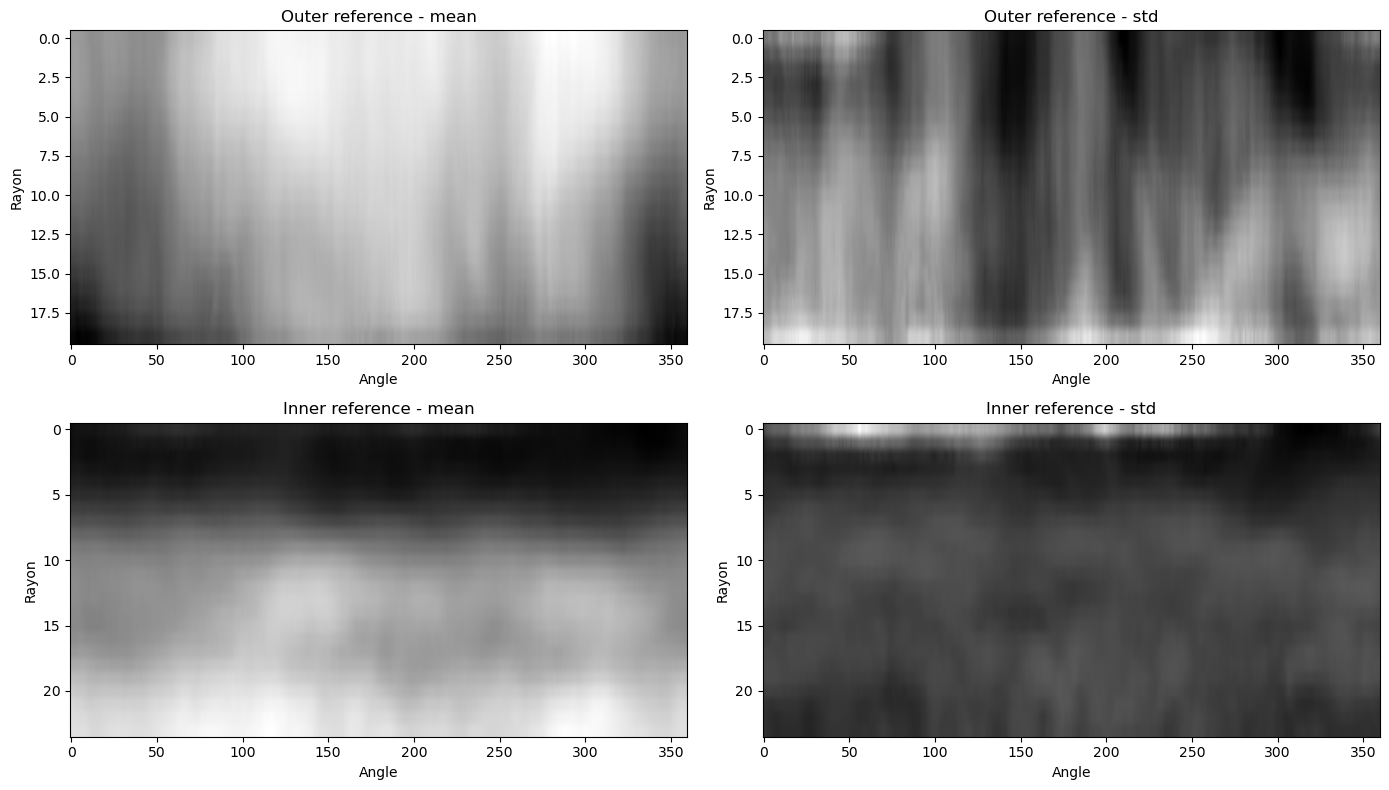

In [37]:
# ==========================================
# 4. Visualiser les références
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].imshow(outer_ref["mean"], cmap="gray", aspect="auto")
axes[0, 0].set_title("Outer reference - mean")

axes[0, 1].imshow(outer_ref["std"], cmap="gray", aspect="auto")
axes[0, 1].set_title("Outer reference - std")

axes[1, 0].imshow(inner_ref["mean"], cmap="gray", aspect="auto")
axes[1, 0].set_title("Inner reference - mean")

axes[1, 1].imshow(inner_ref["std"], cmap="gray", aspect="auto")
axes[1, 1].set_title("Inner reference - std")

for ax in axes.ravel():
    ax.set_xlabel("Angle")
    ax.set_ylabel("Rayon")

plt.tight_layout()
plt.show()

In [38]:
# ==========================================
# 5. Choisir une image OK et une image Defective
# ==========================================

ok_path = random.choice(train_ok_images)
def_path = random.choice(train_def_images)

ok_img = load_grayscale_image(ok_path)
def_img = load_grayscale_image(def_path)

ok_result = analyze_image_with_references(
    ok_img,
    outer_ref,
    inner_ref,
    OUTER_CFG,
    INNER_CFG
)

def_result = analyze_image_with_references(
    def_img,
    outer_ref,
    inner_ref,
    OUTER_CFG,
    INNER_CFG
)

print("OK image       :", ok_path.name)
print("Defective image:", def_path.name)

OK image       : cast_ok_0_9303.jpeg
Defective image: cast_def_0_1994.jpeg


In [39]:
# ==========================================
# 6. Fonction d'affichage
# ==========================================

def show_result(result, title="Analyse"):
    outer_overlay = overlay_mask_on_gray(
        result["piece_only"],
        result["outer_mask_img"],
        color=(255, 0, 0),
        alpha=0.45
    )

    inner_overlay = overlay_mask_on_gray(
        result["piece_only"],
        result["inner_mask_img"],
        color=(255, 0, 0),
        alpha=0.45
    )

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))

    axes[0, 0].imshow(result["prepared"], cmap="gray")
    axes[0, 0].set_title("Image préparée")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(result["mask"], cmap="gray")
    axes[0, 1].set_title("Masque pièce")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(result["outer_strip"], cmap="gray", aspect="auto")
    axes[0, 2].set_title("Outer strip")

    axes[0, 3].imshow(result["outer_res"]["zmap"], cmap="hot", aspect="auto")
    axes[0, 3].set_title(
        f"Outer zmap\n"
        f"ratio={result['outer_res']['abnormal_ratio']:.4f}\n"
        f"run={result['outer_res']['longest_run_ratio']:.4f}"
    )

    axes[1, 0].imshow(outer_overlay)
    axes[1, 0].set_title("Outer overlay")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(inner_overlay)
    axes[1, 1].set_title("Inner overlay")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(result["inner_strip"], cmap="gray", aspect="auto")
    axes[1, 2].set_title("Inner strip")

    axes[1, 3].imshow(result["inner_res"]["zmap"], cmap="hot", aspect="auto")
    axes[1, 3].set_title(
        f"Inner zmap\n"
        f"ratio={result['inner_res']['abnormal_ratio']:.4f}\n"
        f"run={result['inner_res']['longest_run_ratio']:.4f}"
    )

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [46]:
# ==========================================
# 7. Analyse d'un strip par rapport à la référence
# ==========================================

import cv2
import numpy as np

from src.polar_analysis import filter_small_components, longest_true_run_circular


def analyze_strip_against_reference(strip_norm, ref, z_thresh=2.0, min_pixels=10, col_threshold=0.05):
    # خففنا شوية denominator باش anomalies يبانوا أكثر
    zmap = np.abs(strip_norm - ref["mean"]) / (ref["std"] + 0.20)
    zmap_blur = cv2.GaussianBlur(zmap.astype(np.float32), (3, 3), 0)

    binary = np.zeros_like(zmap_blur, dtype=np.uint8)
    binary[zmap_blur >= z_thresh] = 255

    binary = filter_small_components(binary, min_pixels=min_pixels)
    binary_bool = binary > 0

    abnormal_ratio = float(binary_bool.mean())

    col_profile = binary_bool.mean(axis=0)
    abnormal_cols = col_profile >= col_threshold

    abnormal_cols_ratio = float(abnormal_cols.mean())
    longest_run_ratio = float(longest_true_run_circular(abnormal_cols) / len(abnormal_cols))

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

    areas = []
    for label in range(1, num_labels):
        areas.append(stats[label, cv2.CC_STAT_AREA])

    num_components = len(areas)
    max_component_area = int(max(areas)) if len(areas) > 0 else 0

    return {
        "zmap": zmap_blur,
        "binary": binary,
        "abnormal_ratio": abnormal_ratio,
        "abnormal_cols_ratio": abnormal_cols_ratio,
        "longest_run_ratio": longest_run_ratio,
        "num_components": num_components,
        "max_component_area": max_component_area
    }

In [47]:
# ==========================================
# 8. Résumé numérique
# ==========================================

def print_summary(name, result):
    print(f"===== {name} =====")
    print("Outer")
    print(" - abnormal_ratio     :", round(result["outer_res"]["abnormal_ratio"], 6))
    print(" - abnormal_cols_ratio:", round(result["outer_res"]["abnormal_cols_ratio"], 6))
    print(" - longest_run_ratio  :", round(result["outer_res"]["longest_run_ratio"], 6))
    print(" - num_components     :", result["outer_res"]["num_components"])
    print(" - max_component_area :", result["outer_res"]["max_component_area"])

    print("Inner")
    print(" - abnormal_ratio     :", round(result["inner_res"]["abnormal_ratio"], 6))
    print(" - abnormal_cols_ratio:", round(result["inner_res"]["abnormal_cols_ratio"], 6))
    print(" - longest_run_ratio  :", round(result["inner_res"]["longest_run_ratio"], 6))
    print(" - num_components     :", result["inner_res"]["num_components"])
    print(" - max_component_area :", result["inner_res"]["max_component_area"])
    print()

print_summary("OK", ok_result)
print_summary("Defective", def_result)

===== OK =====
Outer
 - abnormal_ratio     : 0.0
 - abnormal_cols_ratio: 0.0
 - longest_run_ratio  : 0.0
 - num_components     : 0
 - max_component_area : 0
Inner
 - abnormal_ratio     : 0.0
 - abnormal_cols_ratio: 0.0
 - longest_run_ratio  : 0.0
 - num_components     : 0
 - max_component_area : 0

===== Defective =====
Outer
 - abnormal_ratio     : 0.008472
 - abnormal_cols_ratio: 0.05
 - longest_run_ratio  : 0.027778
 - num_components     : 2
 - max_component_area : 33
Inner
 - abnormal_ratio     : 0.008102
 - abnormal_cols_ratio: 0.063889
 - longest_run_ratio  : 0.063889
 - num_components     : 1
 - max_component_area : 70



In [48]:
# ==========================================
# 9. Tester sur plusieurs images
# ==========================================

def show_examples(image_paths, class_name, n=2):
    selected = random.sample(image_paths, min(n, len(image_paths)))

    for path in selected:
        img = load_grayscale_image(path)

        result = analyze_image_with_references(
            img,
            outer_ref,
            inner_ref,
            OUTER_CFG,
            INNER_CFG
        )

        outer_overlay = overlay_mask_on_gray(
            result["piece_only"],
            result["outer_mask_img"],
            color=(255, 0, 0),
            alpha=0.45
        )

        inner_overlay = overlay_mask_on_gray(
            result["piece_only"],
            result["inner_mask_img"],
            color=(255, 0, 0),
            alpha=0.45
        )

        fig, axes = plt.subplots(1, 4, figsize=(18, 4))

        axes[0].imshow(result["prepared"], cmap="gray")
        axes[0].set_title("Image")
        axes[0].axis("off")

        axes[1].imshow(outer_overlay)
        axes[1].set_title(
            f"Outer\n"
            f"ratio={result['outer_res']['abnormal_ratio']:.4f}\n"
            f"run={result['outer_res']['longest_run_ratio']:.4f}"
        )
        axes[1].axis("off")

        axes[2].imshow(inner_overlay)
        axes[2].set_title(
            f"Inner\n"
            f"ratio={result['inner_res']['abnormal_ratio']:.4f}\n"
            f"run={result['inner_res']['longest_run_ratio']:.4f}"
        )
        axes[2].axis("off")

        axes[3].imshow(result["outer_res"]["binary"], cmap="gray", aspect="auto")
        axes[3].set_title("Outer binary strip")

        plt.suptitle(f"{class_name} - {path.name}")
        plt.tight_layout()
        plt.show()

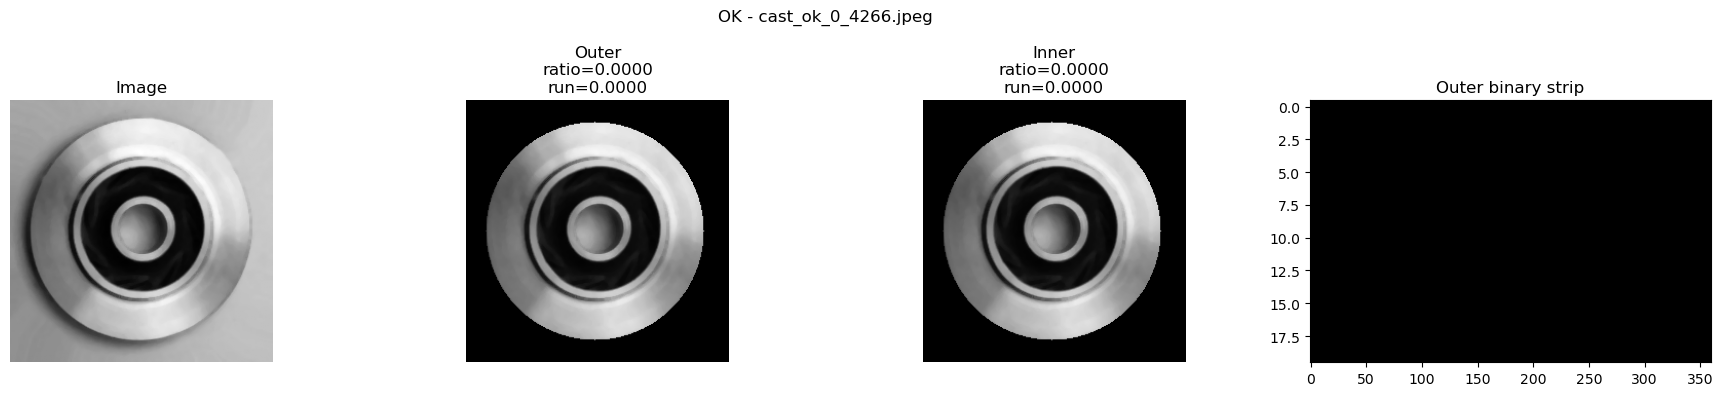

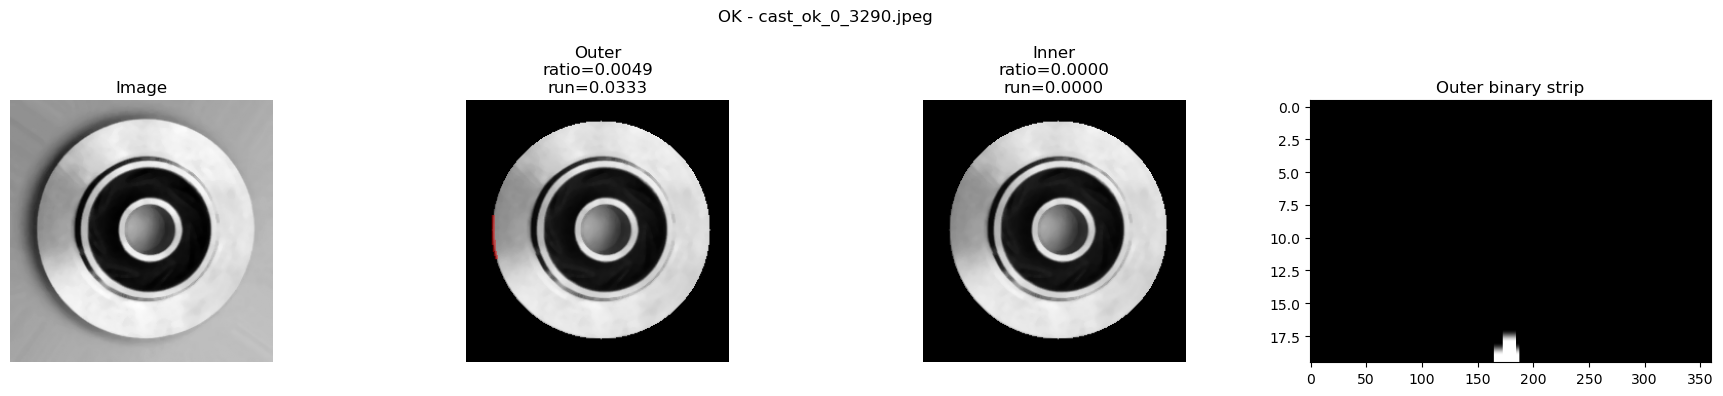

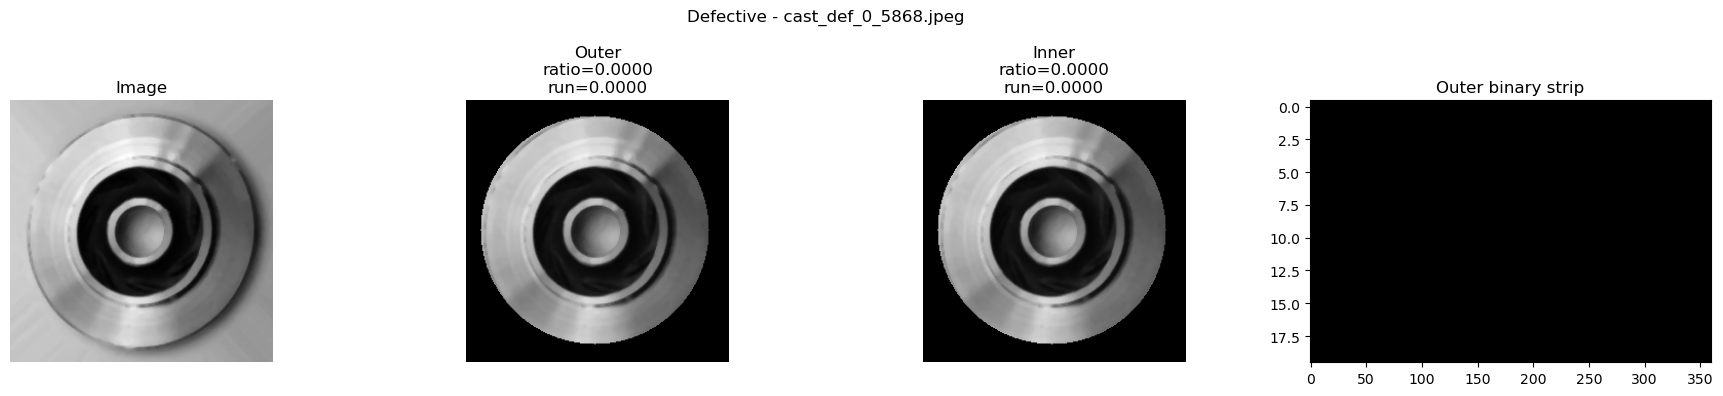

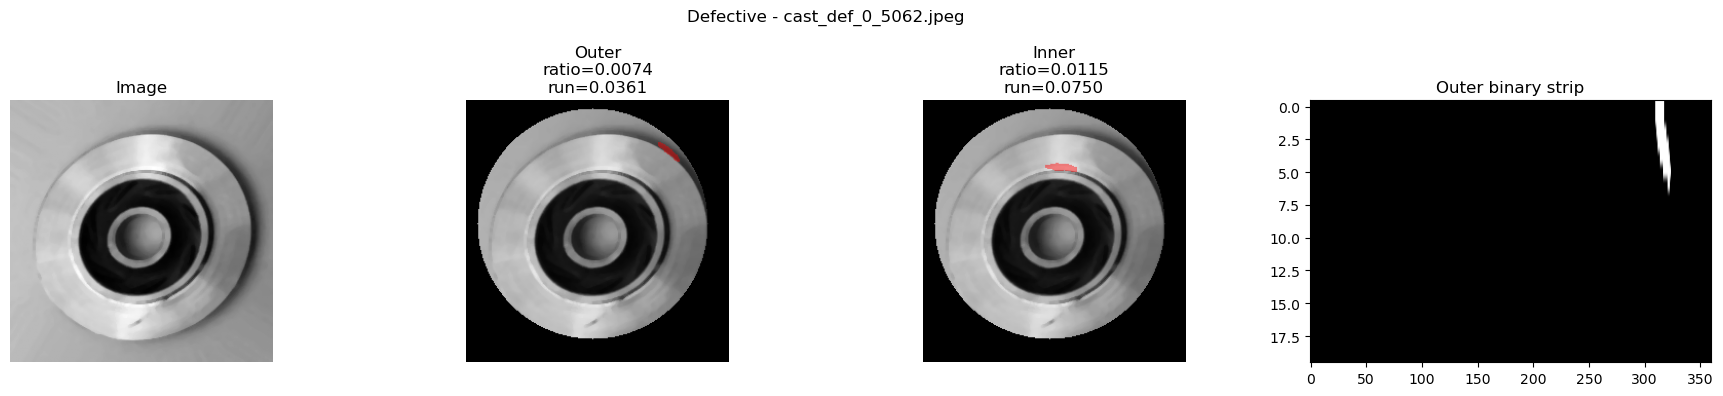

In [49]:
# ==========================================
# 10. Lancer quelques exemples
# ==========================================

show_examples(train_ok_images, "OK", n=2)
show_examples(train_def_images, "Defective", n=2)

In [50]:
# ==========================================
# 11. Extraire les features d'une image
# ==========================================

def extract_features_from_result(result):
    return {
        "outer_abnormal_ratio": result["outer_res"]["abnormal_ratio"],
        "outer_abnormal_cols_ratio": result["outer_res"]["abnormal_cols_ratio"],
        "outer_longest_run_ratio": result["outer_res"]["longest_run_ratio"],
        "outer_num_components": result["outer_res"]["num_components"],
        "outer_max_component_area": result["outer_res"]["max_component_area"],
        "inner_abnormal_ratio": result["inner_res"]["abnormal_ratio"],
        "inner_abnormal_cols_ratio": result["inner_res"]["abnormal_cols_ratio"],
        "inner_longest_run_ratio": result["inner_res"]["longest_run_ratio"],
        "inner_num_components": result["inner_res"]["num_components"],
        "inner_max_component_area": result["inner_res"]["max_component_area"],
    }

print(extract_features_from_result(ok_result))
print(extract_features_from_result(def_result))

{'outer_abnormal_ratio': 0.0, 'outer_abnormal_cols_ratio': 0.0, 'outer_longest_run_ratio': 0.0, 'outer_num_components': 0, 'outer_max_component_area': 0, 'inner_abnormal_ratio': 0.0, 'inner_abnormal_cols_ratio': 0.0, 'inner_longest_run_ratio': 0.0, 'inner_num_components': 0, 'inner_max_component_area': 0}
{'outer_abnormal_ratio': 0.008472222222222223, 'outer_abnormal_cols_ratio': 0.05, 'outer_longest_run_ratio': 0.027777777777777776, 'outer_num_components': 2, 'outer_max_component_area': 33, 'inner_abnormal_ratio': 0.008101851851851851, 'inner_abnormal_cols_ratio': 0.06388888888888888, 'inner_longest_run_ratio': 0.06388888888888888, 'inner_num_components': 1, 'inner_max_component_area': 70}
